## Covariance Based Dynamic Risk Parity Portfolio with Volatility Targeting
### _Written by Matteo Cunsolo_

In [20]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
import seaborn as sns
from scipy.optimize import minimize

#### Let's import all the csvs, check the data and merge it in a single dataframe
##### Taking only the Closing Prices and making it a Pandas Series

In [21]:
#Bonds
path_bonds=Path("CSV_Files/Bonds")
print("______________________")
print("LOADING BONDS...")

for file in path_bonds.glob("*.csv"):
    name=file.stem
    globals()[name]=pd.read_csv(file,header=0, index_col=0, parse_dates=True,
                    na_values=-99.99)
    print(name,"--- Loaded")
#commodities

path_comm=Path("CSV_Files/Commodities")
print("______________________")
print("LOADING COMMODITIES...")

for file in path_comm.glob("*.csv"):
    name=file.stem
    globals()[name] = pd.read_csv(file,header=0, index_col=0, parse_dates=True,
                    na_values=-99.99)["Close"].rename(name)
    print(name,"--- Loaded")
    
print("______________________")
      
#Stocks

path_stocks=Path("CSV_Files/Stocks")
print("LOADING STOCKS...")

for file in path_stocks.glob("*csv"):
    name=file.stem
    globals()[name]=pd.read_csv(file,header=0, index_col=0, parse_dates=True,
                    na_values=-99.99)["Close"].rename(name)
    print(name,"--- Loaded")
print("______________________")

______________________
LOADING BONDS...
Three_Month_US_Treasury_Bill --- Loaded
______________________
LOADING COMMODITIES...
copper --- Loaded
gold --- Loaded
oil --- Loaded
______________________
LOADING STOCKS...
AIG --- Loaded
ATandT --- Loaded
bankofamerica --- Loaded
boeing --- Loaded
citigroup --- Loaded
cocacola --- Loaded
dupont --- Loaded
dupont_out --- Loaded
exxon --- Loaded
fedex --- Loaded
ford --- Loaded
generalelectric --- Loaded
ibm --- Loaded
mcdonalds --- Loaded
merck --- Loaded
proctergamble --- Loaded
southerncompany --- Loaded
sp500 --- Loaded
walmart --- Loaded
______________________


<Axes: >

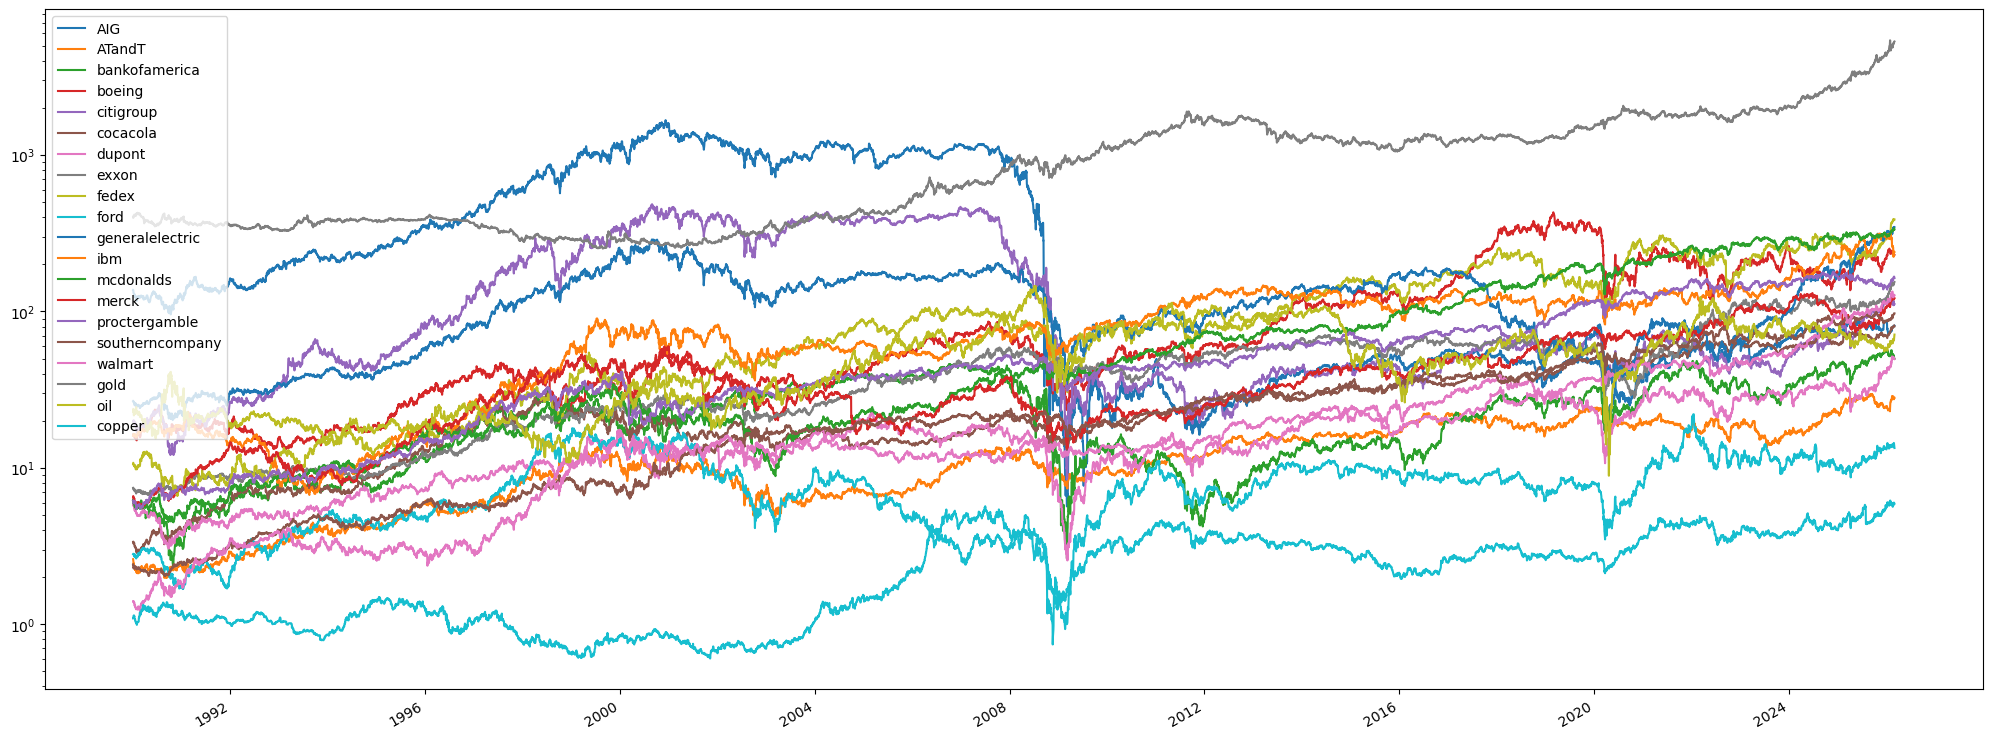

In [22]:
#putting them all togheter into a dataframe
prices=pd.concat([AIG,ATandT,bankofamerica,boeing,citigroup,cocacola,dupont,exxon,fedex,ford,generalelectric,
                  ibm,mcdonalds,merck,proctergamble,southerncompany,walmart,gold,oil,copper], axis=1)

#we are going to forward fill dates with maximum 1 day NaN and then drop furthers NaNs to align on common dates
prices= prices.ffill(limit=1).dropna()
#quick plot of all the assets
prices.plot(figsize=(25,10),logy=True)

#### Calculating the Returns

In [23]:
returns=prices.pct_change()
returns=returns.dropna()

#### Splitting the Data into START and BACKTEST

<Axes: >

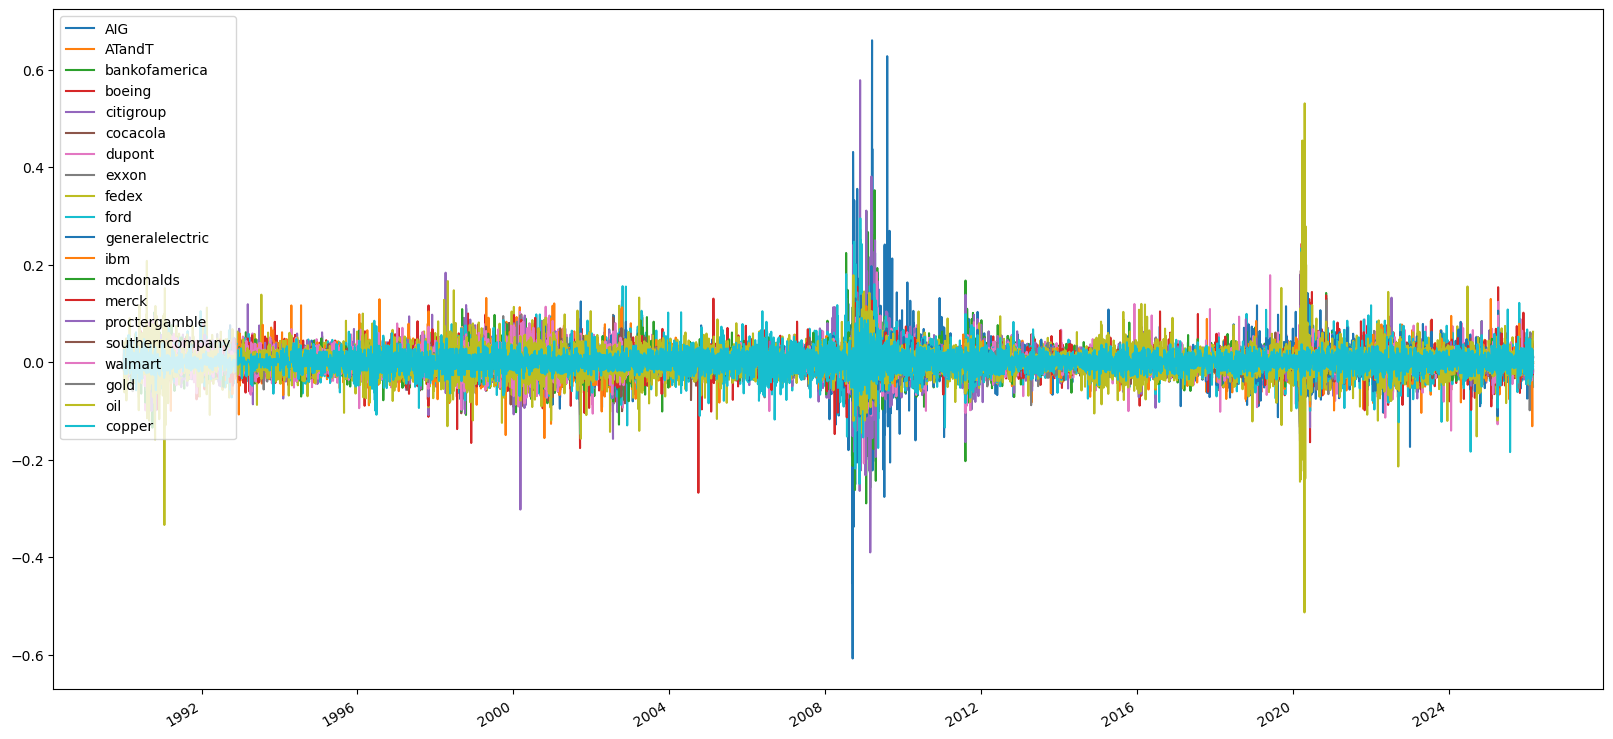

In [24]:
#overal return plots
returns.plot(figsize=(20,10))

Here we can have a visual look at the big crises and the spikes of volatility that came with them

In [25]:
#splitting the returns in two periods
#Start
returns_start=returns.loc["1990":"12-1999"]
#Backtest
returns_backtest=returns.loc["2000":"2026"]

## Covariance Matrix for Start period 1990-1999

In [26]:
cov_start=returns_start.cov()

### To have a better view of the correlation of the assets (in the period 1990-1999) we can compute the correlation matrix and plot it

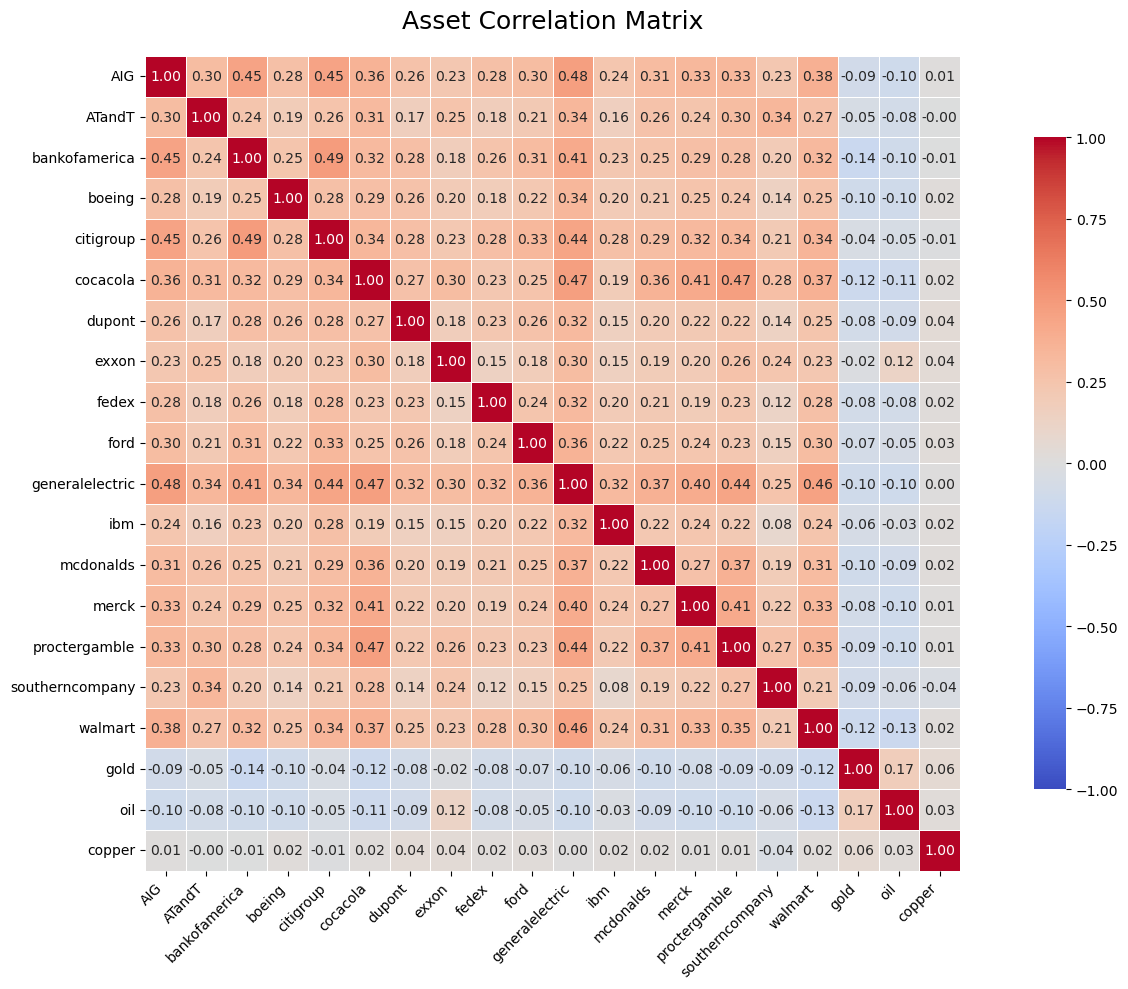

In [27]:
corr = returns_start.corr()
plt.figure(figsize=(15,10))

sns.heatmap(corr,cmap="coolwarm",center=0,vmin=-1,vmax=1,annot=True,fmt=".2f",linewidths=0.5,square=True,cbar_kws={"shrink": .8})
plt.title("Asset Correlation Matrix", fontsize=18, pad=20)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

This heatmap shows the **correlation between the assets in the portfolio**.  
Most **stocks have positive correlations between 0.2 and 0.5**, meaning they often **move in the same direction**.

Commodities such as **gold and oil show low or slightly negative correlation with stocks**, which **helps diversification**.

**Copper is almost uncorrelated with the other assets**, providing **additional diversification in the portfolio**.

## Is this portfolio really diversified? (1990-1999)
#### Let's check

### Effective number of bets (Eigen Values)

In [28]:
eigvals = np.linalg.eigvals(corr)
ENB = (eigvals.sum()**2) / (eigvals**2).sum()
print("Effective Number of Bets:", ENB)

Effective Number of Bets: 9.360861064755003


**The result is ENB 9.36** despite having 20 assets, which is not that bad and signals a good diversification (expected because we constructed it choosing 1 asset from each sector/industry)

### Cumulative Variance of 80% of Portfolio

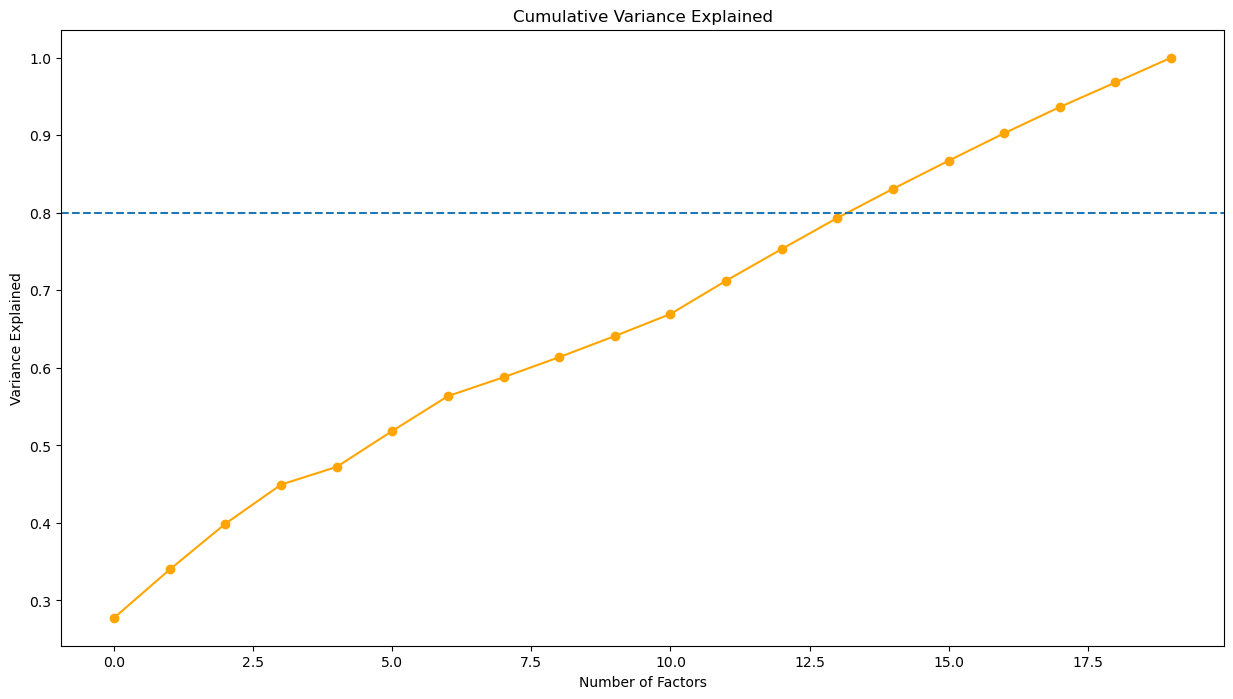

In [29]:
var_explained = eigvals / eigvals.sum()
cum_var = np.cumsum(var_explained)

plt.figure(figsize=(15,8))
plt.plot(cum_var, marker="o",color="orange")
plt.axhline(0.8, linestyle="--")
plt.title("Cumulative Variance Explained")
plt.xlabel("Number of Factors")
plt.ylabel("Variance Explained")
plt.show()

The cumulative variance plot shows how many independent risk factors are needed to explain the portfolio structure. 
**Around 12/13 factors are required to explain approximately 80% of the total variance**, indicating that although the universe contains 20 assets, the effective dimensionality of risk is significantly lower due to correlations between assets.

### Variance by Factor

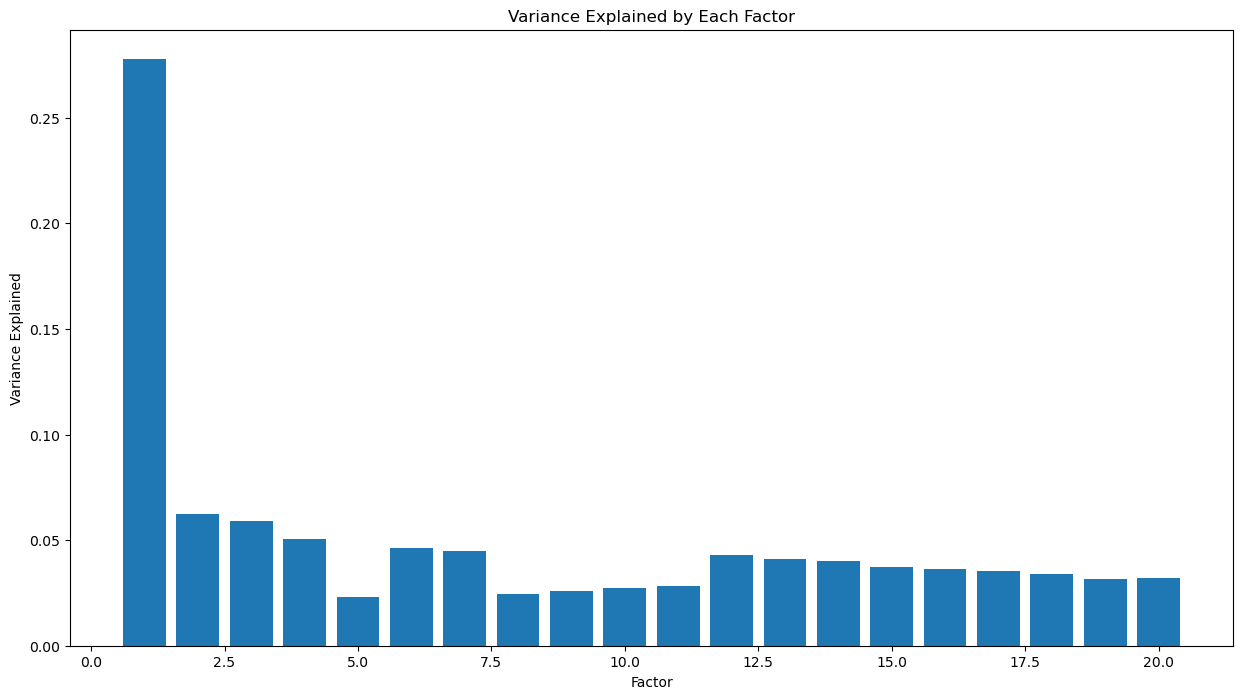

In [30]:
plt.figure(figsize=(15,8))
plt.bar(range(1,len(var_explained)+1), var_explained)
plt.title("Variance Explained by Each Factor")
plt.xlabel("Factor")
plt.ylabel("Variance Explained")
plt.show()

The variance explained by each factor highlights the dominance of the first principal component, which captures the common market movement shared by many equities.  
Subsequent factors contribute progressively smaller portions of variance, representing sector differences, commodity dynamics, and other secondary sources of risk in the portfolio.

**Realistically, given that this are all US Assets + commodities, we could say that the first biggest factor would probably be the US market universe itself**

## Starting Risk Parity Portfolio

In [31]:
# I will define a few functions for easier use afterwards:

def portfolio_vol(weights, covmat):
    """
    Computes the vol of a portfolio from a covariance matrix and constituent weights
    weights are a numpy array or N x 1 maxtrix and covmat is an N x N matrix
    """
    vol = (weights.T @ covmat @ weights)**0.5
    return vol 

import numpy as np
import pandas as pd
from scipy.optimize import minimize

def risk_parity_weights(cov, long_only=True):
    """
    Compute Equal Risk Contribution (Risk Parity) weights given a covariance matrix.
    Returns a pandas Series indexed by asset names.
    """

    assets = cov.columns            # salva i nomi degli asset
    cov = cov.values.astype(float)  # converti in numpy
    n = cov.shape[0]

    # risk contribution shares (sum to 1)
    def rc_shares(w):
        port_var = w.T @ cov @ w
        mrc = cov @ w
        rc = w * mrc
        return rc / port_var

    def objective(w):
        rc = rc_shares(w)
        return ((rc - rc.mean())**2).sum()

    w0 = np.ones(n) / n
    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]

    if long_only:
        bounds = [(0.0, 1.0)] * n
    else:
        bounds = None

    res = minimize(
        objective,
        w0,
        method="SLSQP",
        bounds=bounds,
        constraints=cons,
        options={"maxiter": 20000, "ftol": 1e-12, "disp": False},
    )

    if not res.success:
        raise RuntimeError(f"Risk parity optimizer failed: {res.message}")

    return pd.Series(res.x, index=assets)


# Comaprison functions for later
def CAGR(wealth):
    return (wealth.iloc[-1] / wealth.iloc[0]) ** (252 / len(wealth)) - 1

def max_drawdown(wealth):
    dd = wealth / wealth.cummax() - 1
    return dd.min()

def ann_vol(returns):
    return returns.std() * np.sqrt(252)

def sharpe(returns, rf=0):
    return (returns.mean() * 252 - rf) / (returns.std() * np.sqrt(252))

In [32]:
start_weights=((risk_parity_weights(cov_start)))
start_weights

AIG                0.034377
ATandT             0.041161
bankofamerica      0.030116
boeing             0.037562
citigroup          0.023576
cocacola           0.034934
dupont             0.044703
exxon              0.047833
fedex              0.033272
ford               0.033746
generalelectric    0.033477
ibm                0.037458
mcdonalds          0.039299
merck              0.036076
proctergamble      0.037271
southerncompany    0.065700
walmart            0.031093
gold               0.212428
oil                0.064538
copper             0.081381
dtype: float64

#### Plotting the starting weights at year 2000

<Axes: >

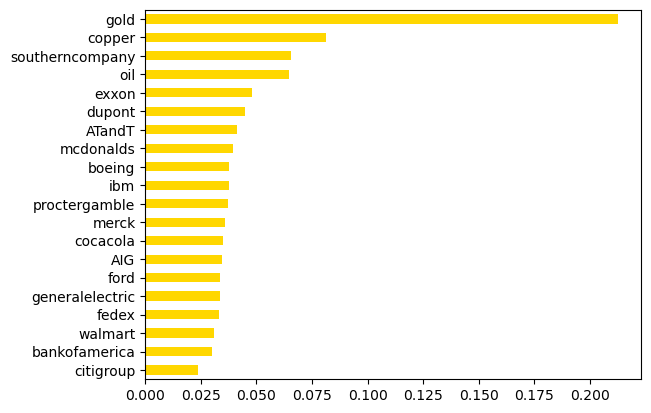

In [33]:
start_weights.sort_values().plot(kind="barh",color="gold")

## Let's initiate our portfolio at year 2000

In [34]:
# At start, we have a portfolio of 10k, 90%in risky assets and 10% in bonds
risky_start=9000*start_weights
bonds_start = pd.Series([1000], index=["bonds"])
portfolio = pd.concat([risky_start, bonds_start])
portfolio

AIG                 309.391999
ATandT              370.445027
bankofamerica       271.043380
boeing              338.057079
citigroup           212.185019
cocacola            314.402547
dupont              402.325189
exxon               430.499546
fedex               299.448630
ford                303.717158
generalelectric     301.294436
ibm                 337.123076
mcdonalds           353.687451
merck               324.682340
proctergamble       335.443405
southerncompany     591.299967
walmart             279.837317
gold               1911.852937
oil                 580.837712
copper              732.425784
bonds              1000.000000
dtype: float64

### Plotting everything in a pie chart to have an overview

<Axes: title={'center': 'Portfolio Composition at starting year 2000'}>

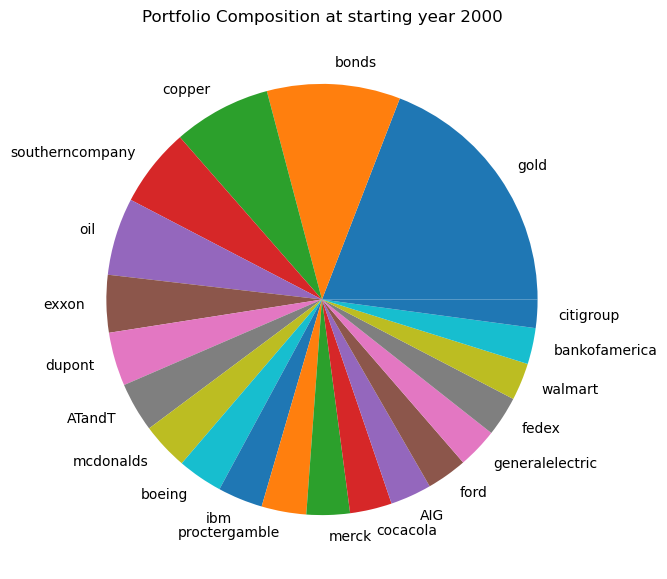

In [35]:
portfolio.sort_values(ascending=False).plot(kind="pie", figsize=(12,7),title="Portfolio Composition at starting year 2000")

In [36]:
# Creating a daily return % for the bonds
returnsbonds=pd.Series([[Three_Month_US_Treasury_Bill/252]])
Three_Month_US_Treasury_Bill = Three_Month_US_Treasury_Bill["DTB3"]
Three_Month_US_Treasury_Bill.index.name = "Date"
bonds_daily_returns = (1 + Three_Month_US_Treasury_Bill/100)**(1/252) - 1
bonds_daily_returns = bonds_daily_returns.loc["2000":]
bonds_daily_returns.name = "bonds"
bonds_daily_returns=bonds_daily_returns.ffill()
risk_free=(Three_Month_US_Treasury_Bill/100).mean()

# Let's start Volatility targeting risky + bonds (2000 - 2026) 

2000-12-21 TOTAL WEALTH --->  10188.70 $
2001-12-14 TOTAL WEALTH --->  9526.33 $
2002-12-06 TOTAL WEALTH --->  9593.93 $
2003-12-02 TOTAL WEALTH --->  10811.85 $
2004-11-29 TOTAL WEALTH --->  12947.79 $
2005-11-16 TOTAL WEALTH --->  13362.65 $
2006-11-07 TOTAL WEALTH --->  15956.65 $
2007-10-29 TOTAL WEALTH --->  18088.65 $
2008-10-15 TOTAL WEALTH --->  13866.80 $
2009-10-02 TOTAL WEALTH --->  15248.83 $
2010-09-21 TOTAL WEALTH --->  17380.74 $
2011-09-08 TOTAL WEALTH --->  18712.82 $
2012-08-27 TOTAL WEALTH --->  20756.88 $
2013-08-15 TOTAL WEALTH --->  23301.20 $
2014-08-05 TOTAL WEALTH --->  24873.24 $
2015-07-23 TOTAL WEALTH --->  24247.11 $
2016-07-19 TOTAL WEALTH --->  26255.39 $
2017-07-12 TOTAL WEALTH --->  29020.70 $
2018-07-02 TOTAL WEALTH --->  30219.59 $
2019-06-24 TOTAL WEALTH --->  33306.33 $
2020-06-11 TOTAL WEALTH --->  31080.92 $
2021-06-01 TOTAL WEALTH --->  40903.04 $
2022-05-20 TOTAL WEALTH --->  41474.96 $
2023-05-09 TOTAL WEALTH --->  44073.36 $
2024-04-25 TOTAL W

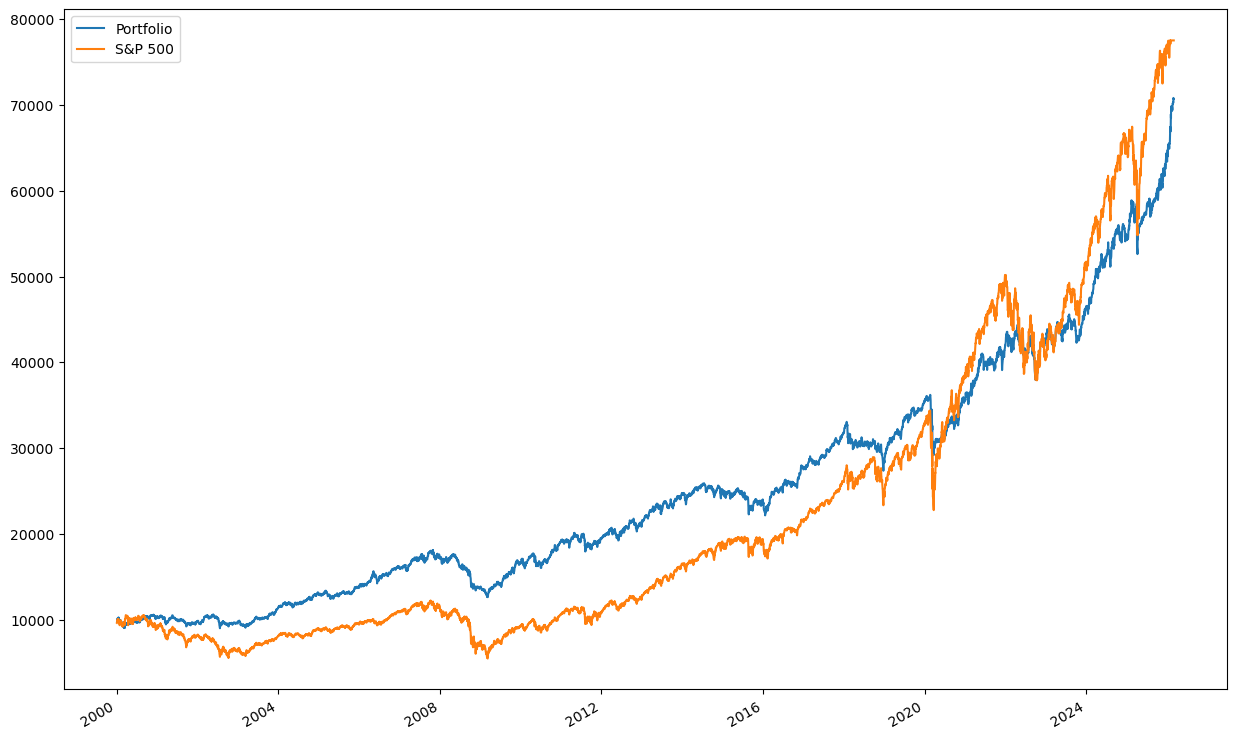

In [37]:
#vol targeting --> exposeure%=voltarget/volatilitymeasured
wealth=0
risky=risky_start
bonds=float(bonds_start.iloc[0])
counts=0
rebcount=1
volatility=0
vtarget=0.12 #volatility target
vw=60 # dimension of the covariance volatility targeting window
current_weights=start_weights
commission=0.02 # % value of commission ---> this value is NOT /100, So 20% is 20 and not 0.2
backtest_results=pd.DataFrame(index=returns_backtest.index, columns=["Wealth", "Returns"])

total_transaction_costs=0  #commission counter
for date, row in returns_backtest.iterrows():

    #step counter
    counts=counts+1
    rebcount=rebcount+1
    
    #wealth -1 memory
    prev_wealth=wealth
    
    # risky asset updated to returns
    risky = risky * (1 + row)

    # bonds sleeve updated to returns
    bonds = bonds * (1 + bonds_daily_returns.loc[date])
    
    # wealth totale
    wealth = risky.sum() + bonds

    if counts % 252 ==0 or counts == len(returns_backtest):
        print(date.date(),"TOTAL WEALTH ---> ", f"{wealth:.2f}","$")
    
    #check volatility dailiy su rolling window di vw giorni
    if counts > vw :
        window=returns_backtest.iloc[counts-vw:counts]
        covmat=window.cov()
        current_weights=risky/risky.sum()
        volatility=portfolio_vol(current_weights,covmat)*np.sqrt(252)
        
        #if counts % 50 ==0:
            #print("____________VOLATILITY CHECK ____________", volatility*100," % ----- target is ",100*vtarget,"%")
        
        scale = vtarget / volatility       
        target_exposure = min(scale, 1.0)   # no leverage: massimo 100% in risky            
        current_risky_value = risky.sum()  # valore attuale del risky sleeve  
        current_bonds_value=bonds
        target_risky_value = wealth * target_exposure   # valore target del risky sleeve      
        
        if current_risky_value > 0:  # riscala risky verso il valore target
            risky = risky * (target_risky_value / current_risky_value)
    
        bonds = wealth - risky.sum()   # il resto va nei bond
        slippage = abs(target_risky_value - current_risky_value)  #interactive brokers slippage
        transaction_costs=slippage*(commission/100)
        total_transaction_costs=total_transaction_costs+transaction_costs
        
        if bonds >= transaction_costs:
               bonds=bonds-transaction_costs
        else:
            # paga riducendo il risky sleeve proporzionalmente
            remaining_cost = transaction_costs - bonds
            bonds = 0
            risky = risky * (1 - remaining_cost / risky.sum())
                            
        #if counts % 50 ==0:
            #print("risky tot before-->",current_risky_value,"bonds tot before-->",current_bonds_value)
            #print("risky tot after-->",risky.sum(),"bonds tot after-->",bonds)
           # print("Transaction costs + slippage ->", f"{transaction_costs:.3f}", "$")
        
    if rebcount % 252 == 0: #every  year we rebalance the riskparity
        #print("____________1 TRADING YEAR MARK, RISK PARITY REBALANCING____________")
        #print(" Old composition --> \n",risky)
        rw=returns_backtest.iloc[counts-(251):counts]
        covmat=rw.cov()
        rebalanced_weights=risk_parity_weights(covmat)
        old_risky = risky.copy()
        risky= risky.sum() * rebalanced_weights
        #print(" New composition --> \n",risky)
        turnover = (risky - old_risky).abs().sum() / 2
        transaction_costs=turnover*(commission/100)
        total_transaction_costs=total_transaction_costs+transaction_costs
        
        if bonds >= transaction_costs:
               bonds=bonds-transaction_costs
        else:
            # paga riducendo il risky sleeve proporzionalmente
            remaining_cost = transaction_costs - bonds
            bonds = 0
            risky = risky * (1 - remaining_cost / risky.sum())                
        #print("Continuing...")
       # print(counts, "Trading days have passed from the start")

    #put wealth into dataframe
    
    backtest_results.loc[date, "Wealth"] = wealth
    
    if prev_wealth != 0:
     backtest_results.loc[date, "Returns"] = wealth / prev_wealth - 1    
        
backtest_results= backtest_results.dropna()
lowest_wealth=backtest_results["Wealth"].min()
highest_wealth=backtest_results["Wealth"].max()
print("_____________BACKTEST ENDED_____________\n"f"TERMINAL WEALTH --> {wealth:.2f} $\n"f"TOTAL TRANSACTION COSTS --> {total_transaction_costs:.2f} $\n"
f"Max Wealth --> {highest_wealth:.2f} $\n"f"Min Wealth --> {lowest_wealth:.2f} $\n")

port_wealth = backtest_results["Wealth"].astype(float)
port_ret = backtest_results["Returns"].astype(float)

#SP500 BENCHMARK
spreturns=sp500.pct_change()
spreturns=spreturns.dropna()
sp_wealth = 10000 * (1 + spreturns).cumprod()
sp_wealth = sp_wealth.astype(float)

##backtest_results["Wealth"].plot(figsize=(15,10), color="green")

#benchmark vs wealth
sp_vs_portfolio = pd.concat([backtest_results["Wealth"], sp_wealth], axis=1)
sp_vs_portfolio = sp_vs_portfolio.astype(float).ffill()
sp_vs_portfolio.columns = ["Portfolio", "S&P 500"]
sp_vs_portfolio.plot(figsize=(15,10))

print("PORTFOLIO STATS")
print(f"CAGR: {CAGR(port_wealth)*100:.2f}%")
print(f"Max Drawdown: {max_drawdown(port_wealth)*100:.2f}%")
print(f"Ann.Volatility: {ann_vol(port_ret)*100:.2f}%")
print(f"Sharpe Ratio: {sharpe(port_ret,risk_free):.2f}")

print("\nS&P500 STATS")
print(f"CAGR: {CAGR(sp_wealth)*100:.2f}%")
print(f"Max Drawdown: {max_drawdown(sp_wealth)*100:.2f}%")
print(f"Ann.Volatility: {ann_vol(spreturns)*100:.2f}%")
print(f"Sharpe Ratio: {sharpe(spreturns,risk_free):.2f}")

# BENCHMARK SECTION
## In this section i will compare our strategy to:
    - Buy and Hold Risk Parity Portfolio (100% Risky Assets)
    - 100% Bonds (3M T-bill, Cashlike)
    - Equal weights Risky + Bonds
    - 60/40 Buy and Hold Risk Parity /Bonds 
    - SP500 TR as before

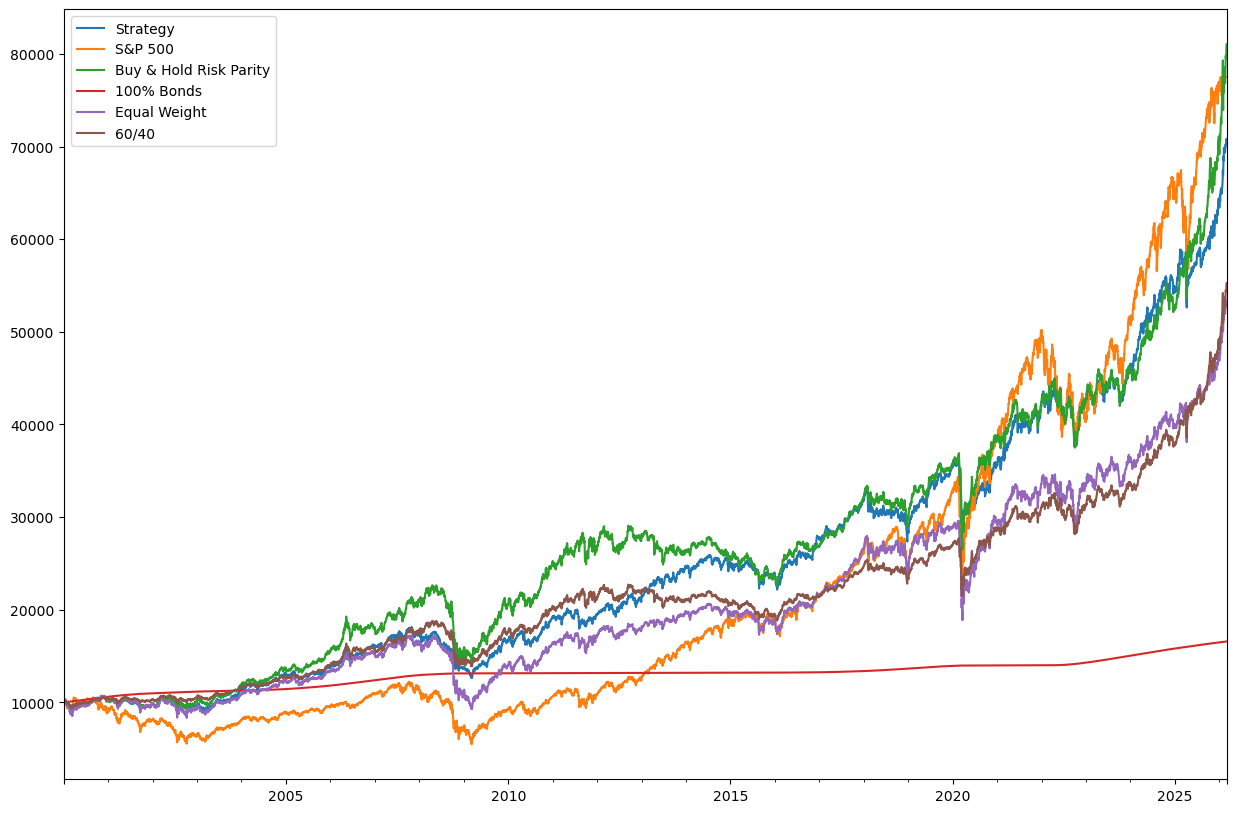


BENCHMARK STATS

                        CAGR %  MaxDD %  Volatility %  Sharpe
Strategy                  7.57   -30.33         10.46    0.49
S&P 500                   8.01   -55.25         18.95    0.36
Buy & Hold Risk Parity    8.12   -36.89         12.74    0.46
100% Bonds                1.88    -0.00          0.12   -7.20
Equal Weight              6.47   -46.09         14.15    0.32
60/40                     6.57   -26.47          9.17    0.44


In [38]:
# Buy Hold risk parity calculated from 1990-1999
investment=10000
risky_start_bh=investment*start_weights
bh_wealth = (1 + returns_backtest).cumprod() * risky_start_bh
bh_wealth = bh_wealth.sum(axis=1)

# 100% Bonds
bonds_100=investment*(1+bonds_daily_returns).cumprod().dropna()

# EW Risky + Bonds
n_risky = returns_backtest.shape[1]
bonds_ew_start = investment / (n_risky + 1)
risky_ew_start = investment / (n_risky + 1)


bonds_ew_wealth=(1+bonds_daily_returns).cumprod()*bonds_ew_start
risky_ew_wealth=((1+returns_backtest).cumprod()*risky_ew_start).sum(axis=1)

EW_wealth=(bonds_ew_wealth+risky_ew_wealth).dropna()

#60/40 Risky / Bonds

bonds_6040_start = investment * 0.4
risky_6040_start=investment*0.6*start_weights


bonds_6040_wealth=(1+bonds_daily_returns).cumprod()*bonds_6040_start
risky_6040_wealth=((1+returns_backtest).cumprod()*risky_6040_start).sum(axis=1)

wealth_6040=(bonds_6040_wealth+risky_6040_wealth).dropna()

#plotting benchmark
BENCHMARK = pd.concat([backtest_results["Wealth"], sp_wealth, bh_wealth, bonds_100, EW_wealth, wealth_6040], axis=1)
BENCHMARK.columns = ["Strategy","S&P 500","Buy & Hold Risk Parity","100% Bonds","Equal Weight","60/40"]

BENCHMARK = BENCHMARK.astype(float).ffill().dropna()
benchmark_returns = BENCHMARK.pct_change().dropna()

BENCHMARK.plot(figsize=(15,10),label=True)
plt.show()
# stats table
stats = []

for col in BENCHMARK.columns:
    
    wealth = BENCHMARK[col]
    returns = benchmark_returns[col]
    
    stats.append([
        CAGR(wealth)*100,
        max_drawdown(wealth)*100,
        ann_vol(returns)*100,
        sharpe(returns,risk_free)
    ])

stats = pd.DataFrame(
    stats,
    index=BENCHMARK.columns,
    columns=["CAGR %","MaxDD %","Volatility %","Sharpe"]
).round(2)

print("\nBENCHMARK STATS\n")
print(stats)

# Conclusion

### Results
The results show that the strategy achieved a **good balance between return and risk** over the period **2000–2026**. Starting from **10,000 USD**, the portfolio grew to **70,690.11 USD**. It reached a **CAGR of 7.62%**, with **annual volatility of 10.50%**, a **maximum drawdown of -30.33%**, and a **Sharpe ratio of 0.76**.

Compared with the **S&P 500**, the strategy produced a **lower return**, but it did so with **much lower volatility** and a **much smaller drawdown**. This means that the strategy was more stable and offered a **better risk adjusted performance**. Compared with the benchmark portfolios, the strategy also had a much better **Sharpe ratio**.

### Limitations
This study also has some important limitations. First, the portfolio is diversified, but **not perfectly diversified**. Even if it includes **20 assets**, the **effective number of bets is only 9.36**, which means that the true diversification is lower than the number of assets suggests.

Second, around **12/13 factors** are needed to explain **80% of the total variance**, and the **first principal component** explains a large part of the risk. This shows that the portfolio is still strongly influenced by **common market movements**, especially the **US market factor**.

Third, the asset universe is still quite limited. It is built mainly with **US stocks**, **commodities**, and a **3-month US Treasury Bill** as the bond component. Because of this, the results may not fully represent a broader global multi-asset portfolio. Finally, transaction costs were included, but the backtest still simplifies real world execution.

### Potential Improvements
To improve the analysis, the portfolio could include a **broader asset universe**, such as **international equities**, **longer duration bonds**, and other **defensive assets**, to improve diversification and the strategy could be tested with **different volatility targets**, **different rebalancing rules**, and **more realistic transaction costs**.

Overall, the strategy shows that combining **risk parity** with **volatility targeting** can be an effective way to reduce drawdowns and improve portfolio stability. However, the results also show that there is still room to build a portfolio that is **more diversified**, **more robust**, and **closer to real market conditions**.